In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import process, fuzz

In [2]:
RANDOM_STATE = 42
K_RANGE = (2,11)
CLUSTER_ORDERS = ['murder', 'bodyfound', 'rape', 'assault', 'kidnap', 'robbery']
PALETTE = ['#7c3aed', '#0ea5e9', '#10b981', '#f59e0b', '#ef4444', "#f65cee", '#06b6d4', '#84cc16']

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print("~ Setup Completely ~")

~ Setup Completely ~


In [3]:
df_raw = pd.read_csv('Bangladesh Crime.csv', delimiter=',')
df = df_raw.copy()
df.tail()

,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,heatindex,season,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
6569,6569,3,10,tuesday,0,night,munshiganj,dhaka,8.5000,9,27,hot,98120,99053,197173,99,4.5500,1399,57.1000,365,27,0,1,17,3,robbery
6570,6570,10,42,saturday,1,night,munshiganj,dhaka,2.6000,10,32,rainy,98120,99053,197173,99,4.5500,1399,57.1000,365,27,0,1,17,3,robbery
6571,6571,3,10,tuesday,0,night,munshiganj,dhaka,NaN,9,27,hot,98120,99053,197173,99,4.5500,1399,57.1000,365,27,0,1,17,3,robbery
6572,6572,1,2,wednesday,0,night,sylhet,sylhet,0.0000,10,17,winter,117354,119783,237137,98,5.8200,893,49.4000,359,1,0,1,19,3,robbery
6573,6573,1,4,tuesday,0,night,pirojpur,barisal,0.0000,10,21,winter,37947,39270,77217,97,4.4400,816,61.2000,286,12,0,2,12,2,robbery


In [4]:
print(f"This dataset contains {df.shape[0]} Rows and {df.shape[1]} Columns with {df.memory_usage(deep=True).sum()/1e6:.2f} MB")

This dataset contains 6574 Rows and 26 Columns with 3.55 MB


In [5]:
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              6574 non-null   int64  
 1   incident_month          6574 non-null   int64  
 2   incident_week           6574 non-null   int64  
 3   incident_weekday        6574 non-null   object 
 4   weekend                 6574 non-null   int64  
 5   part_of_the_day         6457 non-null   object 
 6   incident_district       6574 non-null   object 
 7   incident_division       6574 non-null   object 
 8   precip                  5917 non-null   float64
 9   visibility              6574 non-null   int64  
 10  heatindex               6574 non-null   int64  
 11  season                  6246 non-null   object 
 12  male_population         6574 non-null   int64  
 13  female_population       6574 non-null   int64  
 14  total_population        6574 non-null   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,6574.0000,NaN,NaN,NaN,3286.5000,1897.8947,0.0000,1643.2500,3286.5000,4929.7500,6573.0000
incident_month,6574.0000,NaN,NaN,NaN,6.1932,3.3219,1.0000,3.0000,6.0000,9.0000,12.0000
incident_week,6574.0000,NaN,NaN,NaN,25.1939,14.5180,1.0000,13.0000,25.0000,37.0000,53.0000
incident_weekday,6574,400,tuesday,912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekend,6574.0000,NaN,NaN,NaN,0.2738,0.4459,0.0000,0.0000,0.0000,1.0000,1.0000
part_of_the_day,6457,5,night,3179,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incident_district,6574,64,dhaka,1169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incident_division,6574,9,dhaka,2046,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precip,5917.0000,NaN,NaN,NaN,6.1368,11.7783,0.0000,0.0000,0.8000,7.4000,204.6000
visibility,6574.0000,NaN,NaN,NaN,9.4883,0.9227,4.0000,9.0000,10.0000,10.0000,10.0000


In [6]:
DROP_COLS = ['Unnamed: 0', 'incident_district', 'male_population', 'female_population']
df.drop(columns=DROP_COLS, inplace=True)
print(f"This dataset contains {df.shape[1]} Columns now.")

This dataset contains 22 Columns now.


In [7]:
NUM_FEATURES = ['incident_month', 'incident_week', 'precip', 'visibility', 'heatindex',
                'total_population', 'gender_ration', 'average_household_size', 'density_per_kmsq',
                'literacy_rate', 'religious_institution', 'playground', 'park', 'police_station',
                'school', 'college']
CAT_FEATURES = ['part_of_the_day', 'incident_weekday', 'incident_division', 'season']
BIN_FEATURES = ['weekend']

In [8]:
missing_df = pd.DataFrame({
    'count' : df.isna().sum(),
    'pct (%)' : df.isna().mean().mul(100).round(2)
}).query('count > 0').sort_values('pct (%)', ascending=False)
display(missing_df)

,count,pct (%)
precip,657,9.9900
season,328,4.9900
literacy_rate,328,4.9900
part_of_the_day,117,1.7800


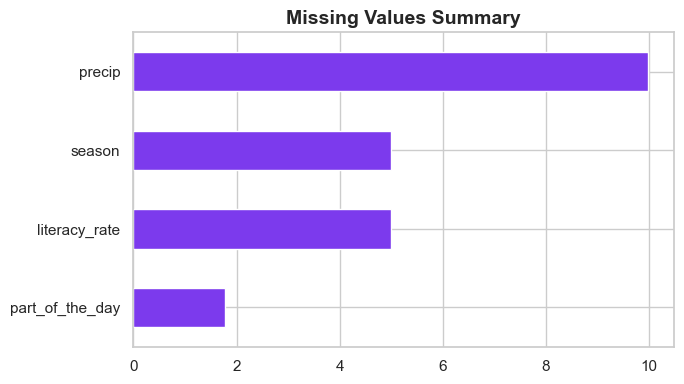

In [9]:
if not missing_df.empty:
    missing_df['pct (%)'].plot(kind='barh', figsize=(7,4), color=PALETTE[0])
    plt.title('Missing Values Summary', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [10]:
df['precip'] = df['precip'].fillna(df['precip'].median())
df['season'] = df['season'].fillna(df['season'].mode()[0])
df['literacy_rate'] = df['literacy_rate'].fillna(df['literacy_rate'].median())
df.dropna(subset=['part_of_the_day'], inplace=True)
print(f"Missing values now: {df.isna().sum().sum()} | Rows remaining: {len(df)}")

Missing values now: 0 | Rows remaining: 6457


In [11]:
duplicates = df.duplicated().sum()
print(f"Duplicates: {duplicates} ({duplicates/len(df)*100:.2f}%)")

Duplicates: 290 (4.49%)


In [12]:
df.drop_duplicates(inplace=True)
print(f"Duplicates now: {df.duplicated().sum()} | Rows remaining: {len(df)}")

Duplicates now: 0 | Rows remaining: 6167


In [13]:
df['incident_weekday'].value_counts(ascending=False)

CORRECT_DAYS = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
df['incident_weekday'] = df['incident_weekday'].str.lower().str.strip()
df['incident_weekday'] = df['incident_weekday'].apply(
    lambda x: process.extractOne(x, CORRECT_DAYS, scorer=fuzz.WRatio)[0]
    if process.extractOne(x, CORRECT_DAYS, scorer=fuzz.WRatio) is not None else x
)
print(df['incident_weekday'].value_counts(ascending=False))

incident_weekday
tuesday      938
wednesday    913
monday       913
thursday     896
saturday     858
friday       833
sunday       816
Name: count, dtype: int64


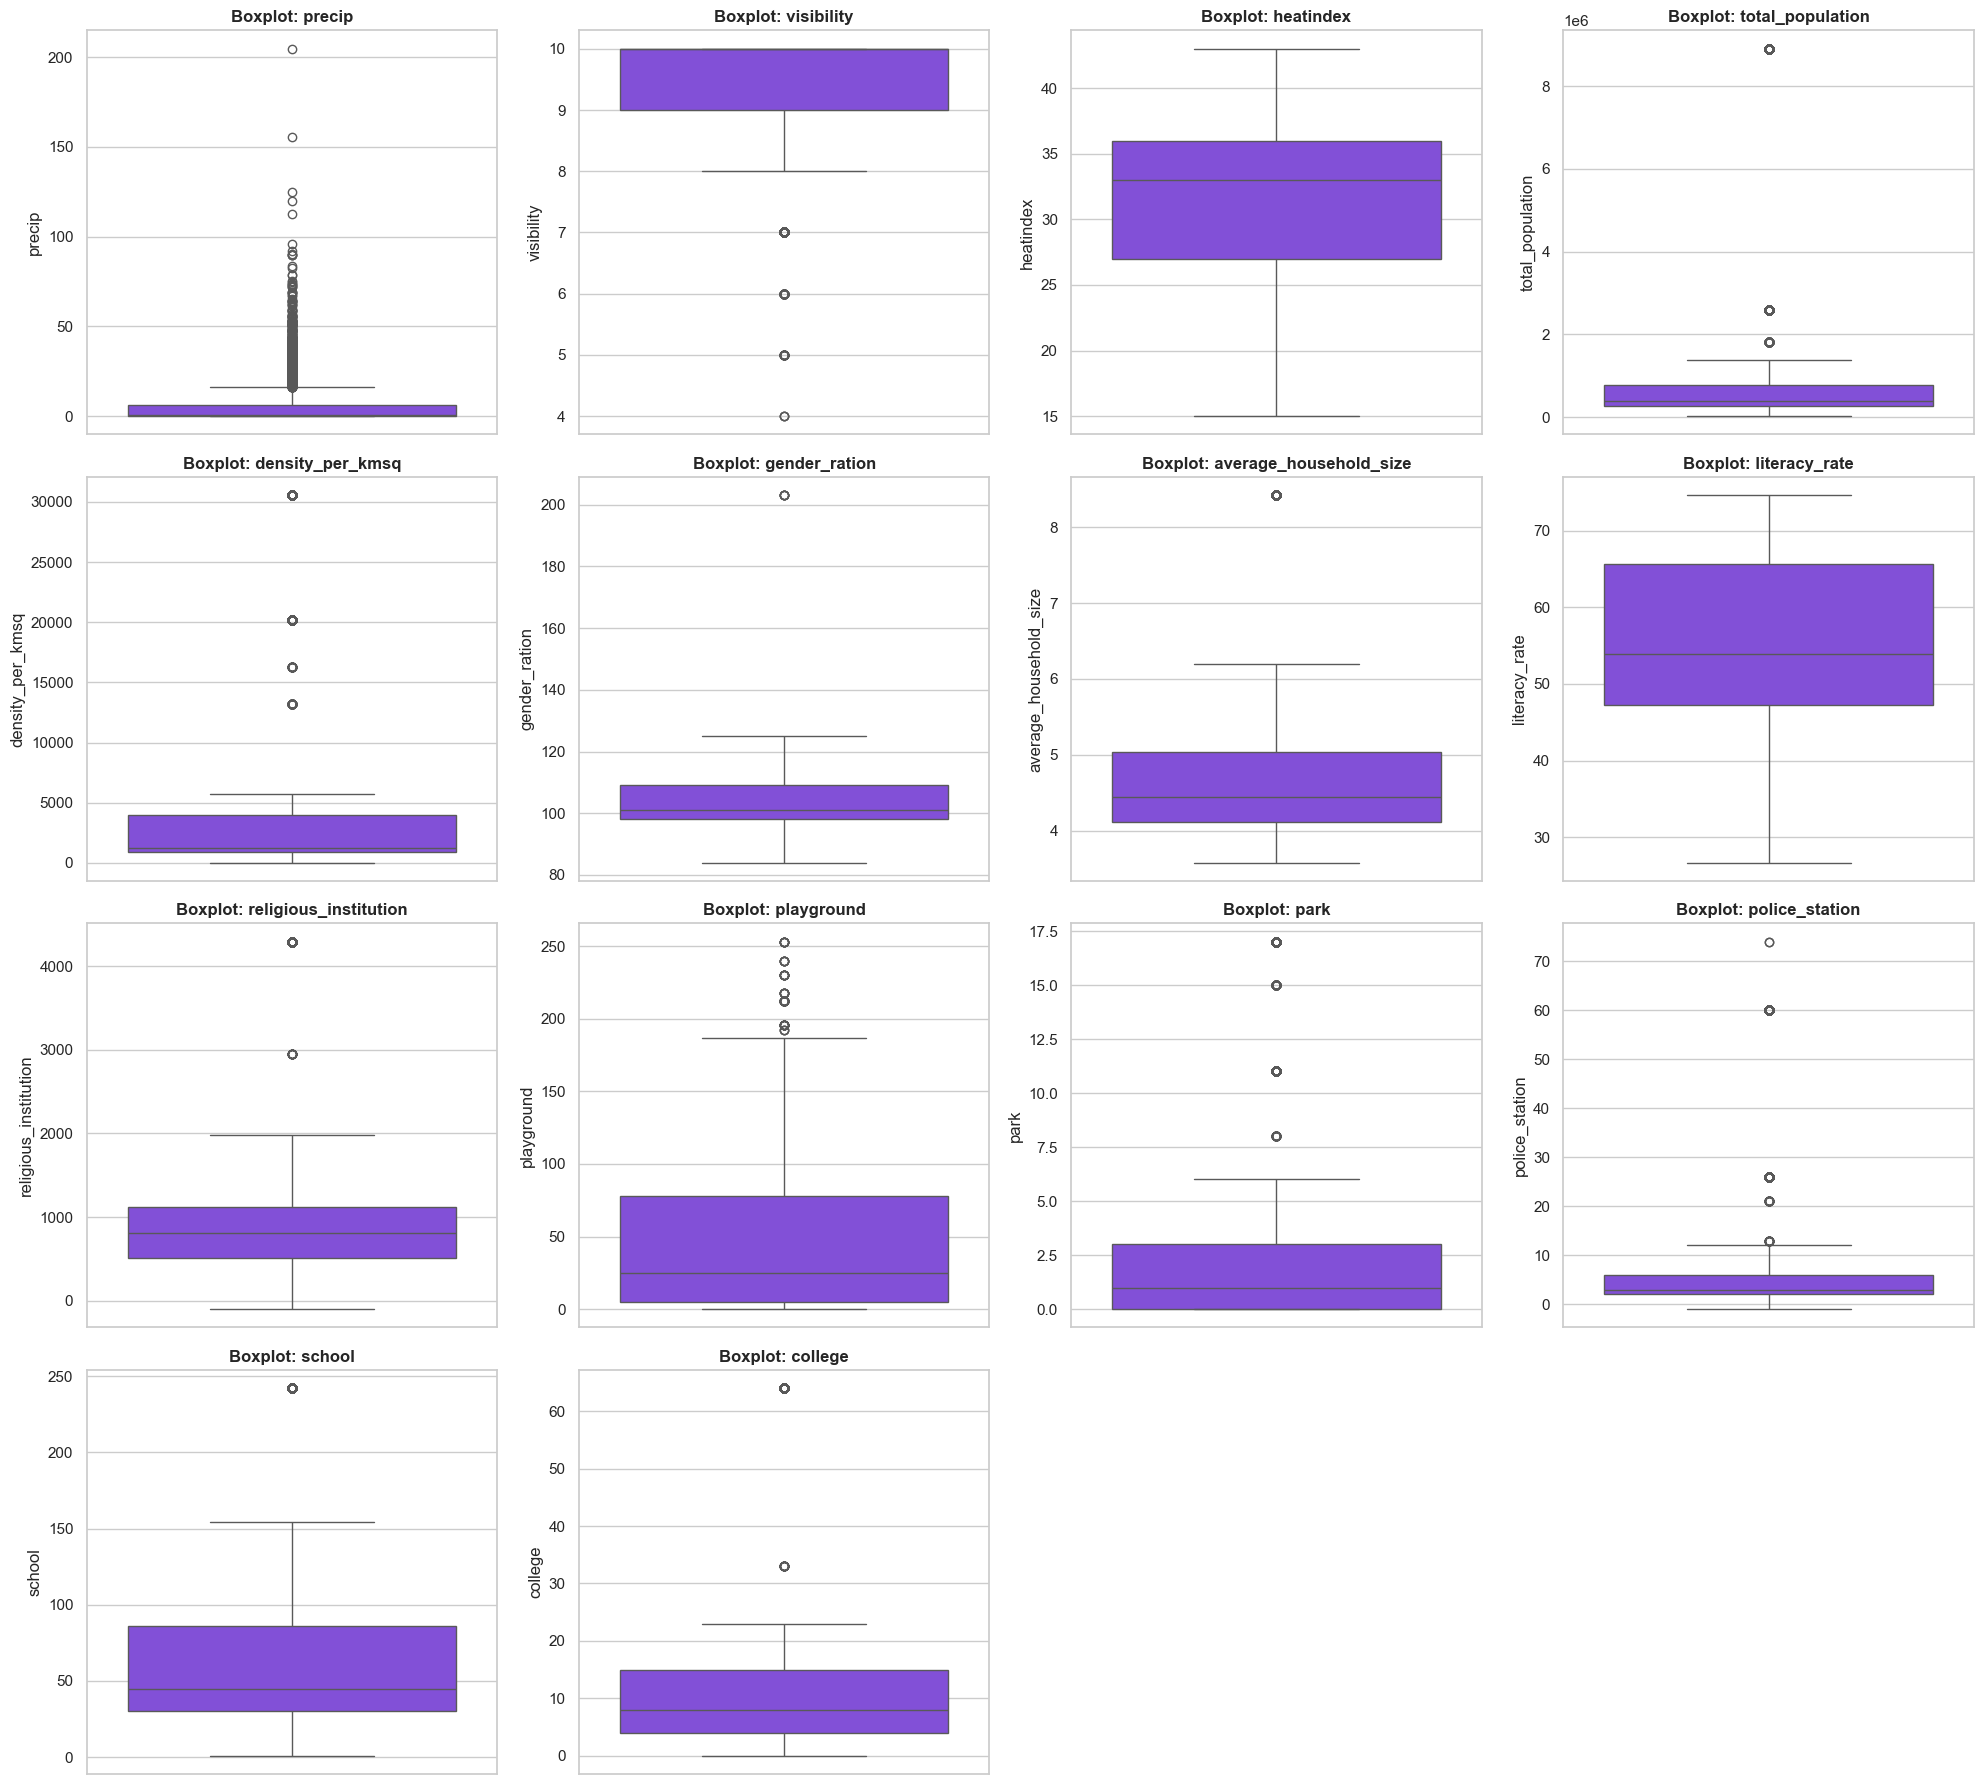

In [14]:
OUTLIER_COLS = ['precip', 'visibility', 'heatindex', 'total_population', 'density_per_kmsq',
                'gender_ration', 'average_household_size', 'literacy_rate', 'religious_institution', 
                'playground', 'park', 'police_station', 'school', 'college']

plt.figure(figsize=(20, 18))
for i, col in enumerate(OUTLIER_COLS, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color=PALETTE[0])
    plt.title(f'Boxplot: {col}', fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
for col in OUTLIER_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col:<30} | Outliers: {n_out}")

precip                         | Outliers: 728
visibility                     | Outliers: 303
heatindex                      | Outliers: 0
total_population               | Outliers: 1178
density_per_kmsq               | Outliers: 1193
gender_ration                  | Outliers: 6
average_household_size         | Outliers: 817
literacy_rate                  | Outliers: 0
religious_institution          | Outliers: 827
playground                     | Outliers: 86
park                           | Outliers: 1216
police_station                 | Outliers: 1148
school                         | Outliers: 817
college                        | Outliers: 839


In [16]:
CLIP_FLOOR_COLS = ['religious_institution', 'playground', 'police_station', 'park', 'school', 'college']
for col in CLIP_FLOOR_COLS:
    df[col] = df[col].clip(lower=0)

WINSORIZE_COLS = ['precip', 'total_population', 'gender_ration', 'average_household_size', 'density_per_kmsq']
for col in WINSORIZE_COLS:
    low, high = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(low, high)

print(f'Final shape after cleaning: {df.shape}')

Final shape after cleaning: (6167, 22)


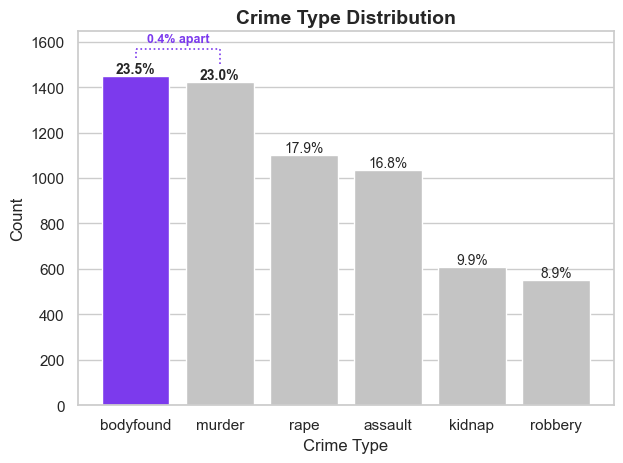

In [17]:
counts = df['crime'].value_counts(ascending=False)
ax = sns.countplot(x='crime', data=df, order=counts.index, color='#c4c4c4')
ax.patches[0].set_facecolor(PALETTE[0])

n = len(df)
for i, p in enumerate(ax.patches):
    ax.text(p.get_x() + p.get_width()/2, p.get_height(),
            f'{p.get_height()/n*100:.1f}%',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold' if i < 2 else 'normal')

b0, b1 = counts.iloc[0], counts.iloc[1]
by = b0 + 120
for xs, ys in [([0,0], [b0+80,by]), ([0,1], [by,by]), ([1,1], [b1+80,by])]:
    ax.plot(xs, ys, color=PALETTE[0], lw=1.2, linestyle='dotted')
ax.text(0.5, by+20, f'{abs(b0-b1)/n*100:.1f}% apart',
        ha='center', va='bottom', fontsize=9, color=PALETTE[0], fontweight='bold')

plt.title('Crime Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Crime Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()